In [2]:

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [5]:
BASE_DIR = r"D:\food safe\dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "test")

print("Train:", os.path.exists(TRAIN_DIR), os.listdir(TRAIN_DIR))
print("Test :", os.path.exists(VAL_DIR), os.listdir(VAL_DIR))


Train: True ['freshapples', 'freshbanana', 'freshcucumber', 'freshokra', 'freshoranges', 'freshpotato', 'freshtomato', 'rottenapples', 'rottenbanana', 'rottencucumber', 'rottenokra', 'rottenoranges', 'rottenpotato', 'rottentomato']
Test : True ['freshapples', 'freshbanana', 'freshcucumber', 'freshokra', 'freshoranges', 'freshpotato', 'freshtomato', 'rottenapples', 'rottenbanana', 'rottencucumber', 'rottenokra', 'rottenoranges', 'rottenpotato', 'rottentomato']


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 21044 images belonging to 14 classes.
Found 6738 images belonging to 14 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # Freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_data.num_classes, activation='softmax')  # 18 classes
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,518 (9.88 MB)

 Trainable params: 331,534 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

EPOCHS = 10

history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=[early_stop]
)


Epoch 1/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 344s 519ms/step - accuracy: 0.7530 - loss: 0.7827 - val_accuracy: 0.8989 - val_loss: 0.3173
Epoch 2/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 343s 521ms/step - accuracy: 0.8921 - loss: 0.3230 - val_accuracy: 0.9259 - val_loss: 0.2264
Epoch 3/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 344s 523ms/step - accuracy: 0.9188 - loss: 0.2482 - val_accuracy: 0.9439 - val_loss: 0.1787
Epoch 4/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 342s 520ms/step - accuracy: 0.9302 - loss: 0.2083 - val_accuracy: 0.9458 - val_loss: 0.1667
Epoch 5/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 341s 518ms/step - accuracy: 0.9377 - loss: 0.1808 - val_accuracy: 0.9503 - val_loss: 0.1546
Epoch 6/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 333s 507ms/step - accuracy: 0.9443 - loss: 0.1649 - val_accuracy: 0.9590 - val_loss: 0.1261
Epoch 7/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 342s 520ms/step - accuracy: 0.9469 - loss: 0.1532 - val_accuracy: 0.9617 - val_loss: 0.1131
Epoch 8/10
658/658 ━━━━━━━━━━━━━━━━━━━━ 343s 521ms/step - accuracy: 0.9534 -

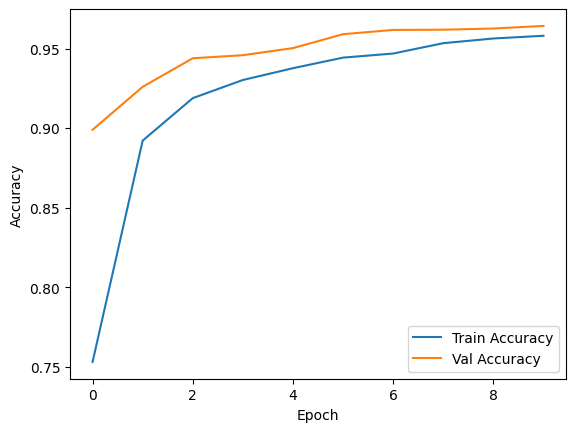

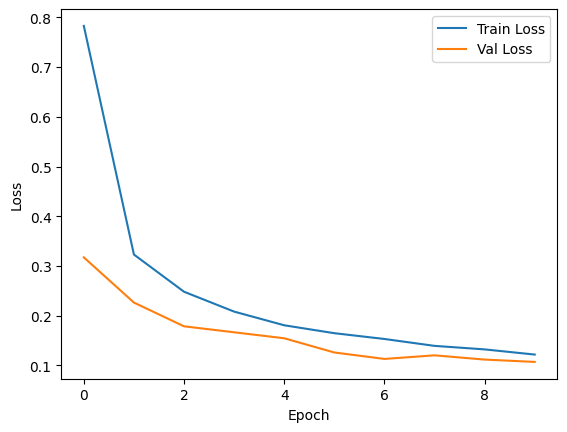

In [9]:

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [10]:
model.save("foodsafe_multiclass_model.h5")
print("Model saved ✅")

Model saved ✅


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


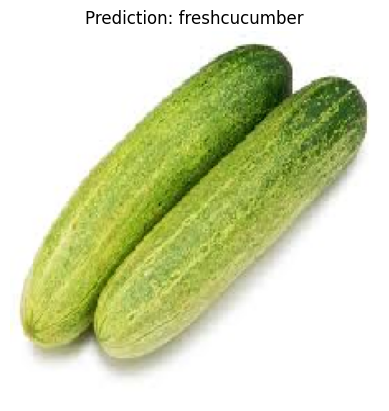

Predicted class index: [2]
Class label: freshcucumber


In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = image.load_img("f cucum.png", target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array_exp = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array_exp)
class_idx = np.argmax(pred, axis=1)
class_label = list(train_data.class_indices.keys())[class_idx[0]]

# Show image with label
plt.imshow(img_array)  # No expand_dims here so it's shape (224,224,3)
plt.axis('off')
plt.title(f"Prediction: {class_label}")
plt.show()

print("Predicted class index:", class_idx)
print("Class label:", class_label)
